In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import sys
from pathlib import Path   
sys.path.append(str(Path.cwd().parent))
from src.path import PROCESSED_DATA_DIR

df = pd.read_csv(PROCESSED_DATA_DIR / "data_with_features.csv")

# Thêm ngay sau dòng: df = pd.read_csv(PROCESSED_DATA_DIR / "data_with_features.csv")



print(df.shape)
print(df.columns.tolist())

(44767, 10)
['label', 'text', 'avg_word_length', 'punctuation_ratio', 'burstiness', 'word_count', 'avg_sentence_length', 'lexical_diversity', 'sentence_count', 'function_word_ratio']


In [2]:

import pandas as pd
from sklearn.model_selection import train_test_split

# ============================================================
# ⚙️ CÀI ĐẶT
# ============================================================
SEED = 42
TEST_SIZE = 0.2   # ✅ 20% Test, 80% Train — nhất quán với RQ1
# ============================================================
# 📥 ĐỌC DỮ LIỆU
# ============================================================
# df = pd.read_csv('../data/processed/data_with_features.csv')  # ← Bỏ dấu # nếu cần đọc từ file

y = df['label']

feature_cols = [
    'avg_word_length', 'punctuation_ratio', 'burstiness',
    'word_count', 'avg_sentence_length', 'lexical_diversity', 'sentence_count','function_word_ratio'
]
X_feat = df[feature_cols].copy()
X_text = df['text'].copy()

# ============================================================
# ✂️ CHIA 80% TRAIN / 20% TEST
# ============================================================
train_idx, test_idx = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED
)

X_train_feat = X_feat.loc[train_idx].reset_index(drop=True)
X_test_feat = X_feat.loc[test_idx].reset_index(drop=True)

X_train_text = X_text.loc[train_idx].reset_index(drop=True)
X_test_text = X_text.loc[test_idx].reset_index(drop=True)

y_train = y.loc[train_idx].reset_index(drop=True)
y_test = y.loc[test_idx].reset_index(drop=True)

# ============================================================
# 🔍 KIỂM TRA
# ============================================================
print("="*60)
print("📊 KẾT QUẢ CHIA DỮ LIỆU 80% TRAIN / 20% TEST")
print("="*60)
print(f"\n📐 Kích thước:")
print(f"  Tổng thể:  {len(df)} mẫu")
print(f"  Train:     {len(X_train_feat)} mẫu ({len(X_train_feat)/len(df):.1%})")
print(f"  Test:      {len(X_test_feat)} mẫu ({len(X_test_feat)/len(df):.1%})")

print(f"\n🎯 Tỷ lệ AI:")
print(f"  Tổng thể:  {y.mean():.1%}")
print(f"  Train:     {y_train.mean():.1%}")
print(f"  Test:      {y_test.mean():.1%}")

print(f"\n✅ Kiểm tra khớp:")
print(f"  X_train_feat ↔ y_train: {len(X_train_feat) == len(y_train)}")
print(f"  X_test_feat  ↔ y_test:  {len(X_test_feat) == len(y_test)}")
print(f"  Mẫu trùng: {len(set(train_idx) & set(test_idx))}")

# ============================================================
# 💾 LƯU FILE
# ============================================================
X_train_feat.to_csv('X_train_feat.csv', index=False)
X_test_feat.to_csv('X_test_feat.csv', index=False)
X_train_text.to_csv('X_train_text.csv', index=False)
X_test_text.to_csv('X_test_text.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print(f"\n💾 Đã lưu 6 file CSV")
print(f"\n⚠️  NGUYÊN TẮC: Tập Test = KHU CẤM — chỉ dùng đánh giá cuối!")

📊 KẾT QUẢ CHIA DỮ LIỆU 80% TRAIN / 20% TEST

📐 Kích thước:
  Tổng thể:  44767 mẫu
  Train:     35813 mẫu (80.0%)
  Test:      8954 mẫu (20.0%)

🎯 Tỷ lệ AI:
  Tổng thể:  39.1%
  Train:     39.1%
  Test:      39.1%

✅ Kiểm tra khớp:
  X_train_feat ↔ y_train: True
  X_test_feat  ↔ y_test:  True
  Mẫu trùng: 0

💾 Đã lưu 6 file CSV

⚠️  NGUYÊN TẮC: Tập Test = KHU CẤM — chỉ dùng đánh giá cuối!


In [3]:
# Ô 1: Load dữ liệu (chạy 1 lần duy nhất)
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                               f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

X_train_feat = pd.read_csv('X_train_feat.csv')
X_test_feat = pd.read_csv('X_test_feat.csv')
X_train_text = pd.read_csv('X_train_text.csv').squeeze()
X_test_text = pd.read_csv('X_test_text.csv').squeeze()
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

SEED = 42

In [4]:
# Ô 2 (ĐẦY ĐỦ NHẤT): TF-IDF + chuẩn hóa + kết hợp + Cross-validation setup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from scipy.sparse import hstack, csr_matrix

# Bước 1: TF-IDF — chỉ fit trên TRAIN
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# Bước 2: Chuẩn hóa 7 đặc trưng số — chỉ fit trên TRAIN
scaler = StandardScaler()
X_train_feat_scaled = scaler.fit_transform(X_train_feat)
X_test_feat_scaled = scaler.transform(X_test_feat)

# Bước 3: Kết hợp
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_feat_scaled)])
X_test_combined = hstack([X_test_tfidf, csr_matrix(X_test_feat_scaled)])

print(f"X_train_combined: {X_train_combined.shape}")
print(f"X_test_combined: {X_test_combined.shape}")

# Bước 4: Chuẩn bị cho Cross-validation và xử lý mất cân bằng (dùng CHUNG cho cả 4 model)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
all_results = []   # ← DÒNG QUAN TRỌNG BỊ THIẾU
print("Đã sẵn sàng: skf và scale_pos_weight")

X_train_combined: (35813, 5008)
X_test_combined: (8954, 5008)
Đã sẵn sàng: skf và scale_pos_weight


Logistic Regression — CV F1: 0.9881 (+/- 0.0008)
{'Model': 'Logistic Regression', 'Accuracy': 0.9917355371900827, 'Precision': 0.9919563343866705, 'Recall': 0.9868533866819091, 'F1': 0.9893982808022923, 'ROC-AUC': 0.9991155257401027, 'CV_F1_mean': np.float64(0.9881308126948035), 'CV_F1_std': np.float64(0.0007748390679790064)}


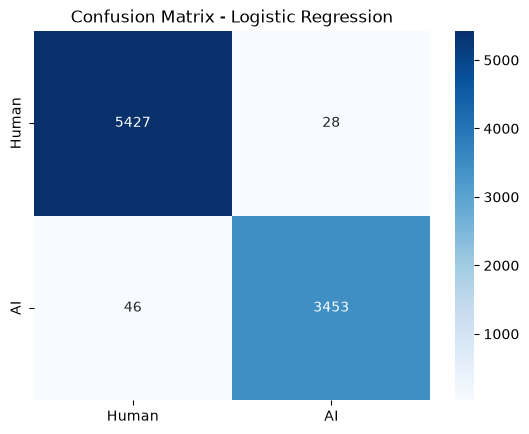

In [5]:
# Ô 3: MODEL 1 — Logistic Regression
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)

# Cross-validation
cv_scores_lr = cross_val_score(model_lr, X_train_combined, y_train, cv=skf, scoring='f1', n_jobs=1)
print(f"Logistic Regression — CV F1: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# Train chính thức + đánh giá trên test
model_lr.fit(X_train_combined, y_train)
y_pred_lr = model_lr.predict(X_test_combined)
y_proba_lr = model_lr.predict_proba(X_test_combined)[:, 1]

result_lr = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lr),
    'CV_F1_mean': cv_scores_lr.mean(),
    'CV_F1_std': cv_scores_lr.std()
}
all_results.append(result_lr)
print(result_lr)

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Random Forest — CV F1: 0.9855 (+/- 0.0016)
{'Model': 'Random Forest', 'Accuracy': 0.9890551708733527, 'Precision': 0.9953393533352752, 'Recall': 0.9765647327807945, 'F1': 0.985862665897288, 'ROC-AUC': 0.9985593107785936, 'CV_F1_mean': np.float64(0.9855350230699909), 'CV_F1_std': np.float64(0.0016415494733803418)}


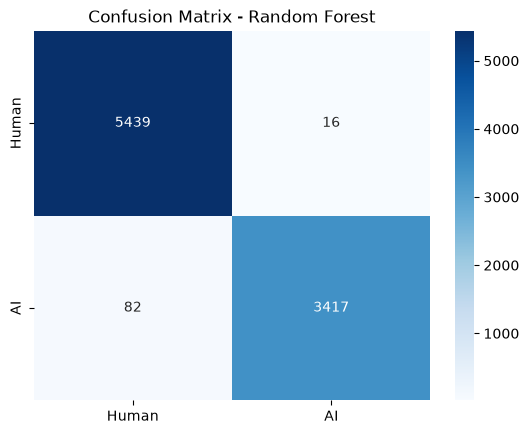

In [6]:
# Ô 4: MODEL 2 — Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1)

cv_scores_rf = cross_val_score(model_rf, X_train_combined, y_train, cv=skf, scoring='f1', n_jobs=1)
print(f"Random Forest — CV F1: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

model_rf.fit(X_train_combined, y_train)
y_pred_rf = model_rf.predict(X_test_combined)
y_proba_rf = model_rf.predict_proba(X_test_combined)[:, 1]

result_rf = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_proba_rf),
    'CV_F1_mean': cv_scores_rf.mean(),
    'CV_F1_std': cv_scores_rf.std()
}
all_results.append(result_rf)
print(result_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title('Confusion Matrix - Random Forest')
plt.show()

LightGBM — CV F1: 0.9927 (+/- 0.0007)
{'Model': 'LightGBM', 'Accuracy': 0.9945275854366763, 'Precision': 0.9971181556195965, 'Recall': 0.9888539582737925, 'F1': 0.9929688621036017, 'ROC-AUC': 0.9995228177017449, 'CV_F1_mean': np.float64(0.9926863963853118), 'CV_F1_std': np.float64(0.0007397593242529579)}


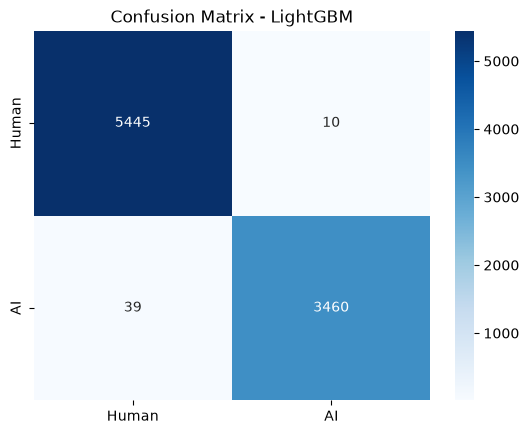

In [7]:
# Ô 5: MODEL 3 — LightGBM
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(n_estimators=200,class_weight='balanced', random_state=SEED, verbose=-1)

cv_scores_lgbm = cross_val_score(model_lgbm, X_train_combined, y_train, cv=skf, scoring='f1', n_jobs=1)
print(f"LightGBM — CV F1: {cv_scores_lgbm.mean():.4f} (+/- {cv_scores_lgbm.std():.4f})")

model_lgbm.fit(X_train_combined, y_train)
y_pred_lgbm = model_lgbm.predict(X_test_combined)
y_proba_lgbm = model_lgbm.predict_proba(X_test_combined)[:, 1]

result_lgbm = {
    'Model': 'LightGBM',
    'Accuracy': accuracy_score(y_test, y_pred_lgbm),
    'Precision': precision_score(y_test, y_pred_lgbm),
    'Recall': recall_score(y_test, y_pred_lgbm),
    'F1': f1_score(y_test, y_pred_lgbm),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lgbm),
    'CV_F1_mean': cv_scores_lgbm.mean(),
    'CV_F1_std': cv_scores_lgbm.std()
}
all_results.append(result_lgbm)
print(result_lgbm)

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title('Confusion Matrix - LightGBM')
plt.show()

XGBoost — CV F1: 0.9918 (+/- 0.0004)
{'Model': 'XGBoost', 'Accuracy': 0.9935224480679026, 'Precision': 0.9965367965367965, 'Recall': 0.9868533866819091, 'F1': 0.9916714531878231, 'ROC-AUC': 0.9993333698327845, 'CV_F1_mean': np.float64(0.9918260920774804), 'CV_F1_std': np.float64(0.00035360692554321945)}


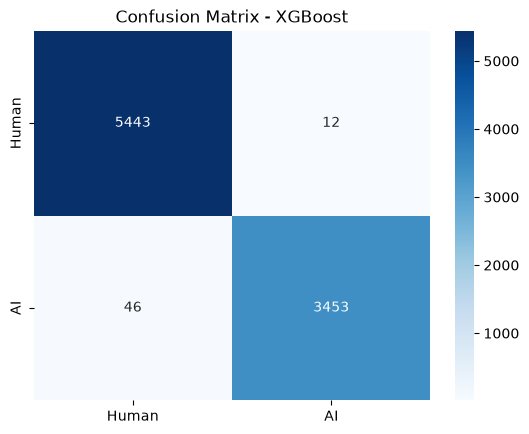

In [8]:
# Ô 6: MODEL 4 — XGBoost
from xgboost import XGBClassifier

model_xgb = XGBClassifier(n_estimators=200,scale_pos_weight=scale_pos_weight, random_state=SEED, eval_metric='logloss')

cv_scores_xgb = cross_val_score(model_xgb, X_train_combined, y_train, cv=skf, scoring='f1', n_jobs=1)
print(f"XGBoost — CV F1: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")

model_xgb.fit(X_train_combined, y_train)
y_pred_xgb = model_xgb.predict(X_test_combined)
y_proba_xgb = model_xgb.predict_proba(X_test_combined)[:, 1]

result_xgb = {
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_proba_xgb),
    'CV_F1_mean': cv_scores_xgb.mean(),
    'CV_F1_std': cv_scores_xgb.std()
}
all_results.append(result_xgb)
print(result_xgb)

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title('Confusion Matrix - XGBoost')
plt.show()

Đang chạy Cross-Validation cho SVM — có thể mất khá lâu...
SVM — CV F1: 0.9888 (+/- 0.0015)
Đang train SVM trên toàn bộ tập train...
{'Model': 'SVM', 'Accuracy': 0.9928523564887202, 'Precision': 0.9965307892454467, 'Recall': 0.9851386110317234, 'F1': 0.9908019545846508, 'ROC-AUC': 0.9992819213241232, 'CV_F1_mean': np.float64(0.9888384533312669), 'CV_F1_std': np.float64(0.0014703403116842553)}


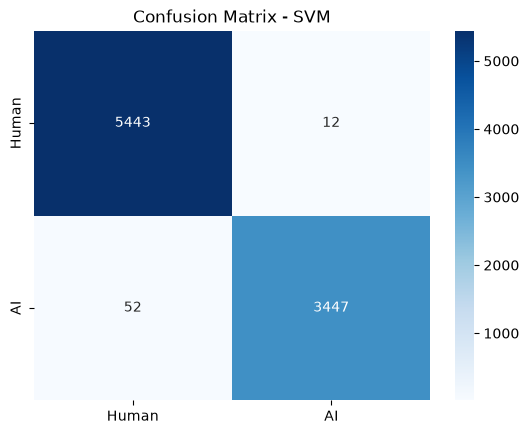

In [9]:
# Ô 7: MODEL 5 — SVM (chuẩn, dùng SVC với kernel RBF)
from sklearn.svm import SVC

model_svm = SVC(
    kernel='rbf',                # kernel chuẩn, phổ biến nhất cho SVM
    class_weight='balanced',     # khớp nguyên tắc với 4 model trước
    #probability=True,            # BẮT BUỘC để có predict_proba → tính ROC-AUC
    random_state=SEED,

    cache_size=2000,          # dùng nhiều RAM hơn để giảm recompute kernel
    shrinking=True              # bật heuristic shrinking, thường nhanh hơn
)

# Cross-validation
print("Đang chạy Cross-Validation cho SVM — có thể mất khá lâu...")
cv_scores_svm = cross_val_score(model_svm, X_train_combined, y_train, cv=skf, scoring='f1', n_jobs=-1)
print(f"SVM — CV F1: {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std():.4f})")

# Train chính thức + đánh giá trên test
print("Đang train SVM trên toàn bộ tập train...")
model_svm.fit(X_train_combined, y_train)
y_pred_svm = model_svm.predict(X_test_combined)
y_score_svm = model_svm.decision_function(X_test_combined)

result_svm = {
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1': f1_score(y_test, y_pred_svm),
    'ROC-AUC': roc_auc_score(y_test, y_score_svm),
    'CV_F1_mean': cv_scores_svm.mean(),
    'CV_F1_std': cv_scores_svm.std()
}
all_results.append(result_svm)
print(result_svm)

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title('Confusion Matrix - SVM')
plt.show()

              Model  Accuracy  Precision   Recall       F1  ROC-AUC  CV_F1_mean  CV_F1_std
           LightGBM  0.994528   0.997118 0.988854 0.992969 0.999523    0.992686   0.000740
            XGBoost  0.993522   0.996537 0.986853 0.991671 0.999333    0.991826   0.000354
                SVM  0.992852   0.996531 0.985139 0.990802 0.999282    0.988838   0.001470
Logistic Regression  0.991736   0.991956 0.986853 0.989398 0.999116    0.988131   0.000775
      Random Forest  0.989055   0.995339 0.976565 0.985863 0.998559    0.985535   0.001642

Đã lưu vào ml_results_summary.csv


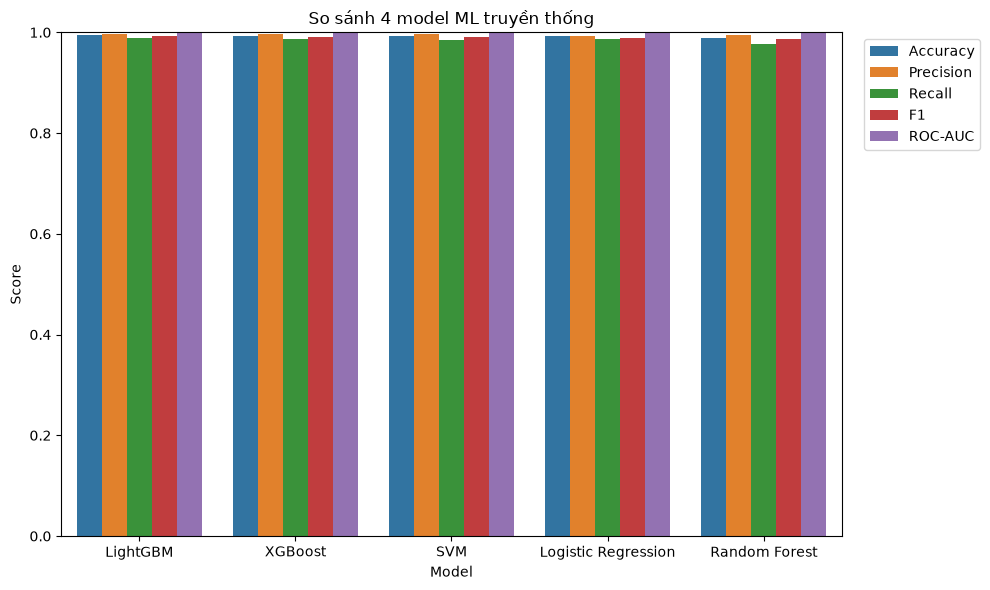

In [10]:
# Ô 7: Tổng hợp kết quả CẢ 4 MODEL (chạy sau khi đã chạy xong Ô 3-6)
results_df = pd.DataFrame(all_results).sort_values('F1', ascending=False)
print(results_df.to_string(index=False))

results_df.to_csv('ml_results_summary.csv', index=False)
print("\nĐã lưu vào ml_results_summary.csv")

plot_df = results_df.melt(id_vars='Model', value_vars=['Accuracy','Precision','Recall','F1','ROC-AUC'],
                            var_name='Metric', value_name='Score')
plt.figure(figsize=(10,6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.title('So sánh 4 model ML truyền thống')
plt.ylim(0,1)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()